In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("07-2025.csv")

In [5]:
df.head()

,Record ID,Activity date,Call direction,Call duration,hs_call_outcome,Activity assigned to
0,82410310914,2025-07-01 08:14,NaN,NaN,NaN,Robin Stoehr
1,82411811914,2025-07-01 09:01,Outbound,00:00:03,NaN,Tyler Jury
2,82411798354,2025-07-01 09:01,Outbound,00:00:02,NaN,Tyler Jury
3,82409530502,2025-07-01 09:02,Outbound,00:00:07,NaN,Tyler Jury
4,82412874844,2025-07-01 09:08,NaN,NaN,NaN,Robin Stoehr


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 14603 entries, 0 to 14602
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Record ID             14603 non-null  int64  
 1   Activity date         14603 non-null  str    
 2   Call direction        13340 non-null  str    
 3   Call duration         13400 non-null  str    
 4   hs_call_outcome       0 non-null      float64
 5   Activity assigned to  13748 non-null  str    
dtypes: float64(1), int64(1), str(4)
memory usage: 1.3 MB


In [9]:
df1 = df.drop(columns=['hs_call_outcome','Record ID'])

In [11]:
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 14603 entries, 0 to 14602
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   Activity date         14603 non-null  str  
 1   Call direction        13340 non-null  str  
 2   Call duration         13400 non-null  str  
 3   Activity assigned to  13748 non-null  str  
dtypes: str(4)
memory usage: 1.0 MB


In [13]:
df1['Activity date'] = pd.to_datetime(
    df1['Activity date'],
    format = "%Y-%m-%d %H:%M",
    errors='coerce'
)

In [15]:
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 14603 entries, 0 to 14602
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Activity date         14603 non-null  datetime64[us]
 1   Call direction        13340 non-null  str           
 2   Call duration         13400 non-null  str           
 3   Activity assigned to  13748 non-null  str           
dtypes: datetime64[us](1), str(3)
memory usage: 827.1 KB


# Call Count per day

In [18]:
df2 = df1.copy()

In [20]:
df2['date'] = df2['Activity date'].dt.date

In [22]:
df2.head()

,Activity date,Call direction,Call duration,Activity assigned to,date
0,2025-07-01 08:14:00,NaN,NaN,Robin Stoehr,2025-07-01
1,2025-07-01 09:01:00,Outbound,00:00:03,Tyler Jury,2025-07-01
2,2025-07-01 09:01:00,Outbound,00:00:02,Tyler Jury,2025-07-01
3,2025-07-01 09:02:00,Outbound,00:00:07,Tyler Jury,2025-07-01
4,2025-07-01 09:08:00,NaN,NaN,Robin Stoehr,2025-07-01


In [24]:
daily_calls = (
    df2.groupby(df2['Activity date'].dt.date)
    .size()
    .reset_index(name='call_count')
    .rename(columns = {'Activity date' : 'date'})
)

In [26]:
daily_calls.head()

,date,call_count
0,2025-07-01,509
1,2025-07-02,571
2,2025-07-03,553
3,2025-07-04,52
4,2025-07-05,10


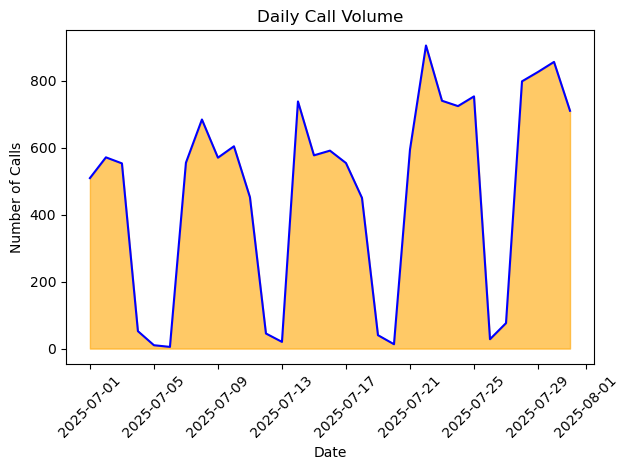

In [28]:
plt.figure()
plt.plot(daily_calls['date'], daily_calls['call_count'],color='blue')

plt.fill_between(daily_calls['date'], daily_calls['call_count'], color='orange', alpha=0.6)

plt.title("Daily Call Volume")
plt.xlabel("Date")
plt.ylabel("Number of Calls")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Count of Call in Weekdays

In [31]:
df1['day'] = df1['Activity date'].dt.day_name()

In [33]:
df1.head()

,Activity date,Call direction,Call duration,Activity assigned to,day
0,2025-07-01 08:14:00,NaN,NaN,Robin Stoehr,Tuesday
1,2025-07-01 09:01:00,Outbound,00:00:03,Tyler Jury,Tuesday
2,2025-07-01 09:01:00,Outbound,00:00:02,Tyler Jury,Tuesday
3,2025-07-01 09:02:00,Outbound,00:00:07,Tyler Jury,Tuesday
4,2025-07-01 09:08:00,NaN,NaN,Robin Stoehr,Tuesday


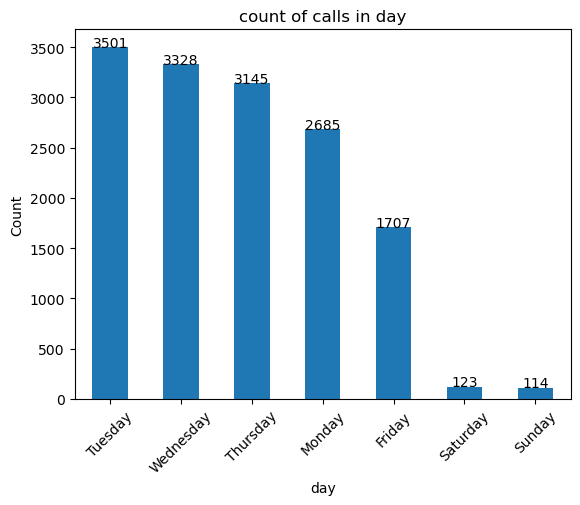

In [35]:
day_Counts = df1["day"].value_counts()
day_Counts.plot(kind='bar')
ax= day_Counts.plot(kind='bar')

for i,v in enumerate(day_Counts):
    ax.text(i, v+1, str(v), ha="center")

plt.title("count of calls in day")
plt.xlabel("day")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# Inbound VS Outbound

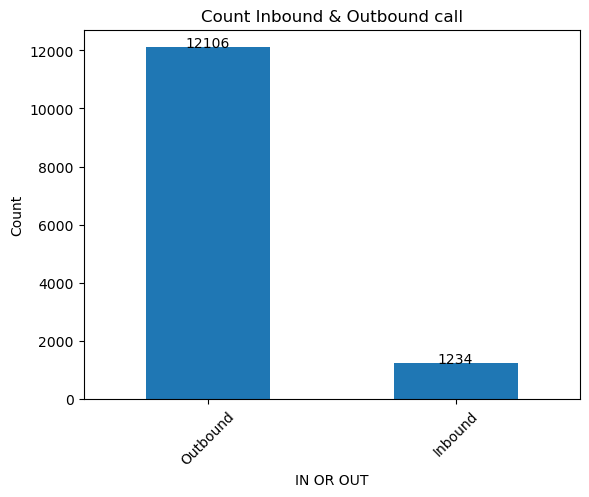

In [38]:
IN_OUT_COUNT = df1['Call direction'].value_counts()
IN_OUT_COUNT.plot(kind='bar')
ax = IN_OUT_COUNT.plot(kind='bar')

for i,v in enumerate(IN_OUT_COUNT):
    ax.text(i, v+1, str(v), ha="center")

plt.title("Count Inbound & Outbound call")
plt.xlabel("IN OR OUT")
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

# Count 00 Duration for Bound

In [41]:
N_B = df1[(df1['Call duration'] == "00:00:00")]

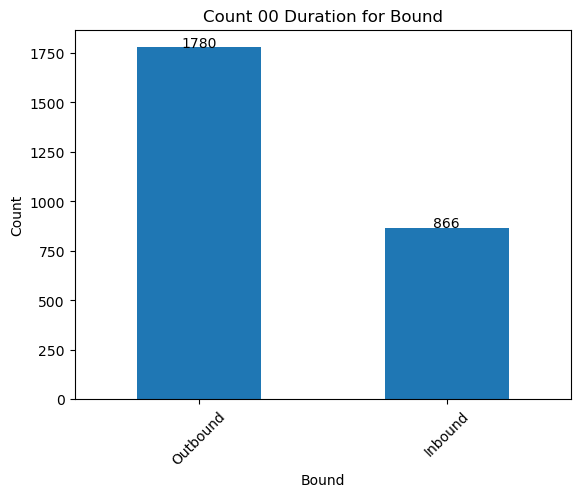

In [43]:
N_B_Counts = N_B['Call direction'].value_counts()
N_B_Counts.plot(kind="bar")
ax = N_B_Counts.plot(kind="bar")

for i,v in enumerate(N_B_Counts):
    ax.text(i, v+1, str(v), ha="center")

plt.title("Count 00 Duration for Bound")
plt.xlabel("Bound")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# Call duration NULL but have Call direction

In [46]:
df1[(df1['Call duration'].isnull()) & (df1['Call direction'].notnull())]

,Activity date,Call direction,Call duration,Activity assigned to,day
1332,2025-07-03 15:35:00,Inbound,NaN,Robin Stoehr,Thursday
1405,2025-07-03 17:11:00,Outbound,NaN,Christian Banks,Thursday
2602,2025-07-08 15:28:00,Inbound,NaN,Robin Stoehr,Tuesday
4676,2025-07-14 10:58:00,Outbound,NaN,Tommy Canfield,Monday
5036,2025-07-14 16:23:00,Outbound,NaN,Christian Banks,Monday
5616,2025-07-15 16:19:00,Inbound,NaN,Robin Stoehr,Tuesday
8570,2025-07-22 15:58:00,Outbound,NaN,Tommy Canfield,Tuesday
10759,2025-07-25 13:05:00,Outbound,NaN,Tommy Canfield,Friday
11675,2025-07-28 14:42:00,Inbound,NaN,Robin Stoehr,Monday


In [48]:
df4 = df1.copy()

In [50]:
df4['Call duration'] = (
    pd.to_timedelta(df4['Call duration'], errors = 'coerce')
    .dt.total_seconds()/60
)

In [52]:
(df4['Call duration'] == 0).sum()

2646

In [54]:
df4['Call duration'] = df4['Call duration'].fillna(0)

In [ ]:
df4 = df4.dropna(subset = ['Call direction'])